#5.1 범주형 변수의 기술통계

##실행5_1_1. 범주형 변수의 기술통계: 1변수

In [321]:
#주로 사용하는 library import
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

#data : raw data 형식 (students 데이터)
from google.colab import drive
#구글 드라이브 마운트(연결)
drive.mount('/content/drive')
#드라이브에 저장된 파일 경로 지정
file_path = '/content/drive/MyDrive/Colab_ex_data/students.csv'
#데이터프레임 만들기
df_students = pd.read_csv(file_path)
print(df_students.head())
print(df_students.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   id   grade major  math  english  science
0   1  grade1     A    50       98       50
1   2  grade1     A    60       97       60
2   3  grade1     A    45       86       78
3   4  grade1     A    30       98       58
4   5  grade1     A    25       80       65
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       50 non-null     int64 
 1   grade    50 non-null     object
 2   major    50 non-null     object
 3   math     50 non-null     int64 
 4   english  50 non-null     int64 
 5   science  50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None


In [322]:
#모든 범주형 변수의 빈도표 출력하기
category_col = df_students.select_dtypes(include=['object', 'category']).columns  #columns는 컬럼 이름들의 목록만 반환
print(category_col)

Index(['grade', 'major'], dtype='object')


In [323]:
for col in category_col:
  print(f"\n[{col} frequency table]")
  print(df_students[col].value_counts()) #특정 열에 대해서 빈도를 세어줌


[grade frequency table]
grade
grade2    19
grade1    15
grade3    10
grade4     6
Name: count, dtype: int64

[major frequency table]
major
A    23
C    14
B    13
Name: count, dtype: int64


In [324]:
#모든 범주형 변수의 빈도표 출력하기 - total 추가
for col in category_col:
 print(f"\n[{col} frequency table including total]")
 freq = df_students[col].value_counts()
 freq.loc['total'] = freq.sum() #합계 행 추가 (, 없으니까 행만)
 print(freq)


[grade frequency table including total]
grade
grade2    19
grade1    15
grade3    10
grade4     6
total     50
Name: count, dtype: int64

[major frequency table including total]
major
A        23
C        14
B        13
total    50
Name: count, dtype: int64


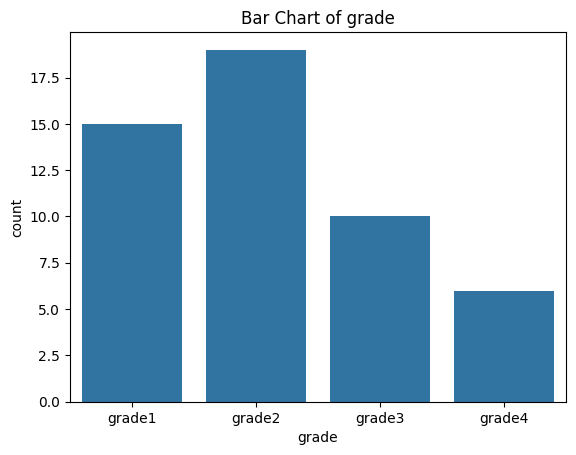

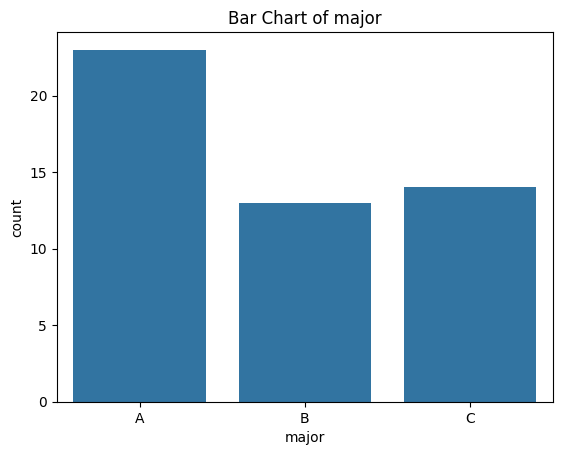

In [325]:
#모든 범주형 변수의 막대그래프 출력하기
for col in category_col:
  sns.countplot(x=col, data=df_students)
  plt.title(f"Bar Chart of {col}")
  plt.show()

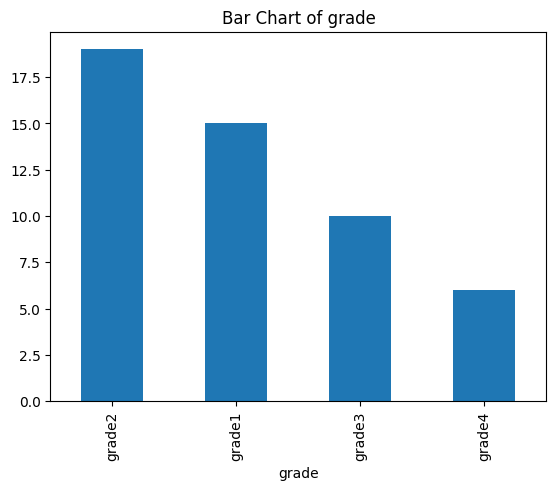

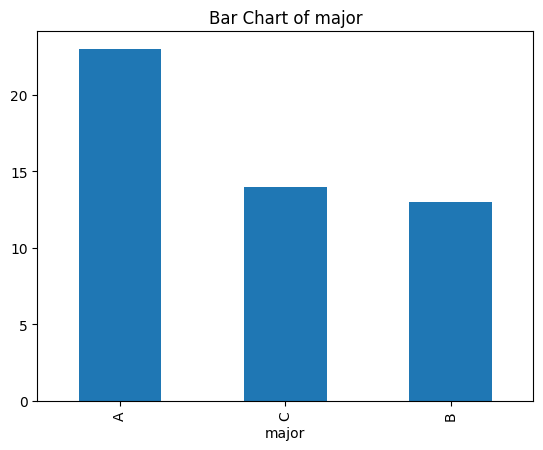

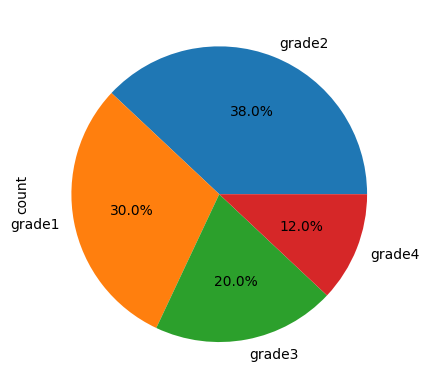

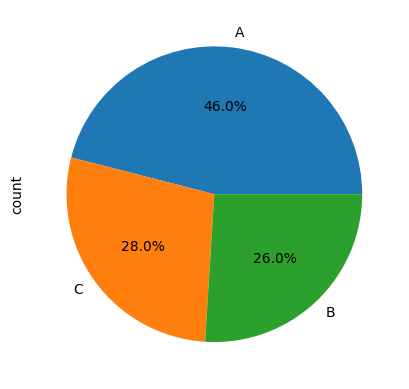

In [326]:
#모든 범주형 변수의 막대그래프 출력하기 plot 사용
for col in category_col:
 df_students[col].value_counts().plot(kind='bar')         #pandas 함수
 #kind 옵션 'bar', 'pie', 'box', 'kde', 'line', ''scatter'
 plt.title(f"Bar Chart of {col}")
 plt.show()
 #모든 범주형 변수의 파이그래프 출력하기 plot 사용
for col in category_col:
 df_students[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
 #kind 옵션 'bar', 'pie', 'box', 'kde', 'line', ''scatter' plt.title(f"Pie Chart of {col}")
 plt.show()

##실행5_1_2. 범주형 변수의 기술통계: 2변수

In [327]:
#crosstab 이원분할표 (교차표)
print("[Two-way Frequency Table]")
students_ct1 = pd.crosstab(index=df_students['grade'], columns=df_students['major'], margins=True) #margins=True 없으면 All이 안나옴
print(students_ct1)

[Two-way Frequency Table]
major    A   B   C  All
grade                  
grade1   8   4   3   15
grade2   9   4   6   19
grade3   4   3   3   10
grade4   2   2   2    6
All     23  13  14   50


In [328]:
#crosstab 교차표 비율로 표시
#전체합계기준
print("\n[Proportion Table : Overall Ratio]")
students_ct2 = pd.crosstab(df_students['grade'], df_students['major'], margins=True, normalize='all')
print(students_ct2)

#행기준(행합계 1)
print("\n[Proportion Table : Row-wise]")
students_ct3 = pd.crosstab(df_students['grade'], df_students['major'], margins=True, normalize='index')
print(students_ct3)

#열기준(열합계 1)
print("\n[Proportion Table : Column-wise]")
students_ct4 = pd.crosstab(df_students['grade'], df_students['major'], margins=True, normalize='columns') ; print(students_ct4)

#crosstab 교차표 퍼센트
print("\n[Proportion Table : Overall %]")
students_ct5 = pd.crosstab(df_students['grade'], df_students['major'], margins=True, normalize='all')*100 # *100을 하면 퍼센트로 나옴
print(students_ct5)


[Proportion Table : Overall Ratio]
major      A     B     C   All
grade                         
grade1  0.16  0.08  0.06  0.30
grade2  0.18  0.08  0.12  0.38
grade3  0.08  0.06  0.06  0.20
grade4  0.04  0.04  0.04  0.12
All     0.46  0.26  0.28  1.00

[Proportion Table : Row-wise]
major          A         B         C
grade                               
grade1  0.533333  0.266667  0.200000
grade2  0.473684  0.210526  0.315789
grade3  0.400000  0.300000  0.300000
grade4  0.333333  0.333333  0.333333
All     0.460000  0.260000  0.280000

[Proportion Table : Column-wise]
major          A         B         C   All
grade                                     
grade1  0.347826  0.307692  0.214286  0.30
grade2  0.391304  0.307692  0.428571  0.38
grade3  0.173913  0.230769  0.214286  0.20
grade4  0.086957  0.153846  0.142857  0.12

[Proportion Table : Overall %]
major      A     B     C    All
grade                          
grade1  16.0   8.0   6.0   30.0
grade2  18.0   8.0  12.0   38.0
grade

In [329]:
#pivot_table 이원분할표 (교차표)
students_pt1 = pd.pivot_table(data=df_students,
 index='grade',  #index는 행변수
 columns='major',  #colums는 열변수
 values='id', #어떤 열이든 (행 개수 세는 것) #grade별 major의 수학의 수를 세고 싶으면 '수학'을 써야 함
 aggfunc='count', #각 조합의 행 개수
 fill_value=0, #결측값(NaN) 을 지정한 값으로 표시, 생략시 NaN으로 표시
 margins=True)
print(students_pt1)

major    A   B   C  All
grade                  
grade1   8   4   3   15
grade2   9   4   6   19
grade3   4   3   3   10
grade4   2   2   2    6
All     23  13  14   50


In [330]:
#pivot_table 교차표 비율로 표시
#전체합계 기준
print("\n[Proportion Table : Overall Ratio]")
students_pt2 = students_pt1 / students_pt1.loc['All', 'All'] #행과 열이 모두 'All'인 셀: 피벗 테이블의 총 합계
print(students_pt2)

#행기준(행합계 1)
print("\n[Proportion Table : Row-wise]")
students_pt3 = students_pt1.div(students_pt1['All'], axis=0)

#div 는 데이터프레임(DataFrame)의 나눗셈을 수행, 축(axis)기준 설정
students_pt3 = students_pt1.div(students_pt1.loc[:, 'All'], axis=0) #행기준, 세로방향으로 연산
print(students_pt3)

#열기준(열합계 1)
print("\n[Proportion Table : Column-wise]")
students_pt4 = students_pt1.div(students_pt1.loc['All'], axis=1)
students_pt4 = students_pt1.div(students_pt1.loc['All', :], axis=1) #열기준, 가로방향으로 연산
print(students_pt4)

#크로스탭과는 다르게 합이 1이 나오는 것도 표현됨

#교차표 퍼센트
print("\n[Proportion Table : Overall %]")
students_pt5 = students_pt2 * 100
print(students_pt5)


[Proportion Table : Overall Ratio]
major      A     B     C   All
grade                         
grade1  0.16  0.08  0.06  0.30
grade2  0.18  0.08  0.12  0.38
grade3  0.08  0.06  0.06  0.20
grade4  0.04  0.04  0.04  0.12
All     0.46  0.26  0.28  1.00

[Proportion Table : Row-wise]
major          A         B         C  All
grade                                    
grade1  0.533333  0.266667  0.200000  1.0
grade2  0.473684  0.210526  0.315789  1.0
grade3  0.400000  0.300000  0.300000  1.0
grade4  0.333333  0.333333  0.333333  1.0
All     0.460000  0.260000  0.280000  1.0

[Proportion Table : Column-wise]
major          A         B         C   All
grade                                     
grade1  0.347826  0.307692  0.214286  0.30
grade2  0.391304  0.307692  0.428571  0.38
grade3  0.173913  0.230769  0.214286  0.20
grade4  0.086957  0.153846  0.142857  0.12
All     1.000000  1.000000  1.000000  1.00

[Proportion Table : Overall %]
major      A     B     C    All
grade                  

In [331]:
print(df_students.head())

   id   grade major  math  english  science
0   1  grade1     A    50       98       50
1   2  grade1     A    60       97       60
2   3  grade1     A    45       86       78
3   4  grade1     A    30       98       58
4   5  grade1     A    25       80       65


In [332]:
#추가설명
print(df_students.mean(axis=0,numeric_only=True))  #행들을 사용해서 평균을 냄 = 행기준, 열별 평균, 세로방향
print(df_students.mean(axis=1,numeric_only=True))  #열들을 사용해서 평균을 냄 = 열기준, 행별 평균, 가로방향

id         25.50
math       59.82
english    84.28
science    63.14
dtype: float64
0     49.75
1     54.75
2     53.00
3     47.50
4     43.75
5     52.25
6     57.25
7     55.50
8     50.00
9     46.25
10    60.50
11    65.00
12    64.25
13    58.25
14    54.50
15    63.25
16    58.00
17    52.75
18    38.00
19    53.25
20    54.00
21    46.00
22    66.25
23    61.00
24    55.75
25    41.00
26    56.25
27    57.00
28    49.00
29    63.00
30    61.25
31    55.75
32    63.25
33    58.00
34    61.00
35    45.75
36    61.50
37    64.75
38    67.50
39    63.50
40    48.25
41    64.00
42    67.25
43    70.00
44    73.25
45    72.50
46    66.50
47    75.25
48    74.50
49    68.50
dtype: float64


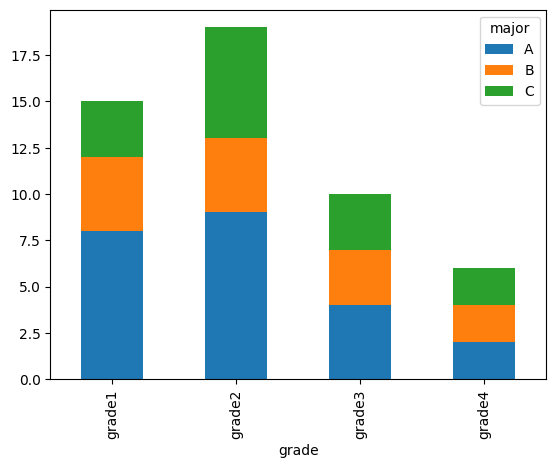

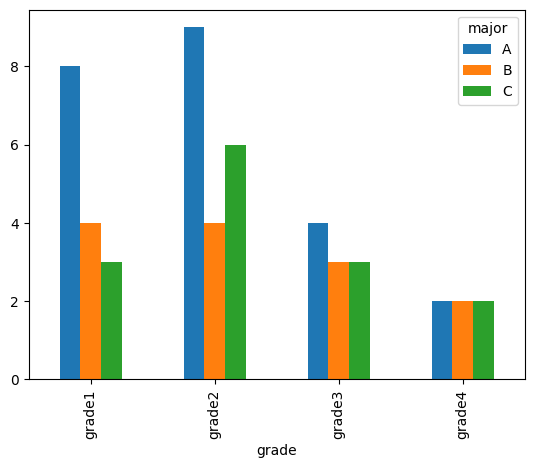

major   A  B  C
grade          
grade1  8  4  3
grade2  9  4  6
grade3  4  3  3
grade4  2  2  2


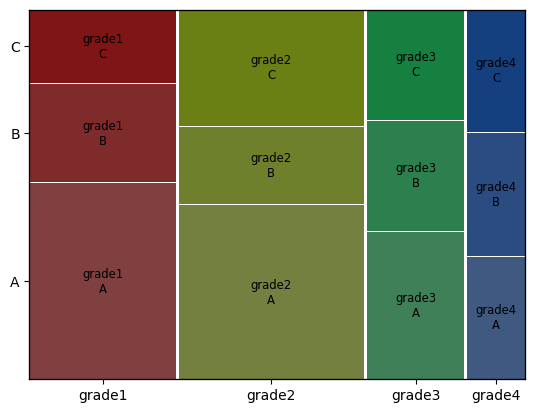

In [333]:
#두 개 범주형 변수에 대한 막대그래프
students_plot = pd.crosstab(df_students['grade'], df_students['major'])
students_plot.plot(kind='bar', stacked=True); plt.show()
students_plot.plot(kind='bar', stacked=False); plt.show()
print(students_plot)

#모자이크 그림
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df_students, ['grade', 'major']); plt.show()

##연습5_1_1

In [334]:
#데이터 불러오기
df_titanic=sns.load_dataset('titanic')  #seaborn 제공, 바로 데이터프레임 형태로 출력
print(df_titanic)
print(df_titanic.info())

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

In [335]:
#숫자형 속성 범주 변수를 범주형 속성으로 변환
df_titanic['pclass']=df_titanic['pclass'].astype('category')
df_titanic['survivied']=df_titanic['survived'].astype('category')

In [336]:
#모든 범주형 변수의 빈도표 출력하기 - total 추가
category_col = df_titanic.select_dtypes(include=['object','category','bool']).columns

for col in category_col:
  print(f"\n[{col} frequency table including total]")
  freq=df_titanic[col].value_counts()
  freq.loc['total']=freq.sum()  #합계 행 추가
  print(freq)


[pclass frequency table including total]
pclass
3        491
1        216
2        184
total    891
Name: count, dtype: int64

[sex frequency table including total]
sex
male      577
female    314
total     891
Name: count, dtype: int64

[embarked frequency table including total]
embarked
S        644
C        168
Q         77
total    889
Name: count, dtype: int64

[class frequency table including total]
class
Third     491
First     216
Second    184
total     891
Name: count, dtype: int64

[who frequency table including total]
who
man      537
woman    271
child     83
total    891
Name: count, dtype: int64

[adult_male frequency table including total]
adult_male
True     537
False    354
total    891
Name: count, dtype: int64

[deck frequency table including total]
deck
C         59
B         47
D         33
E         32
A         15
F         13
G          4
total    203
Name: count, dtype: int64

[embark_town frequency table including total]
embark_town
Southampton    644
Cherbo

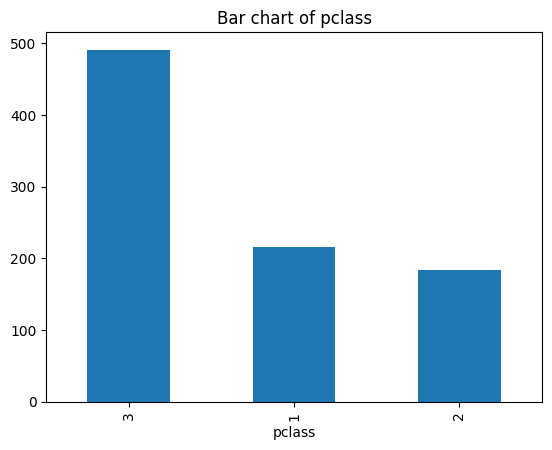

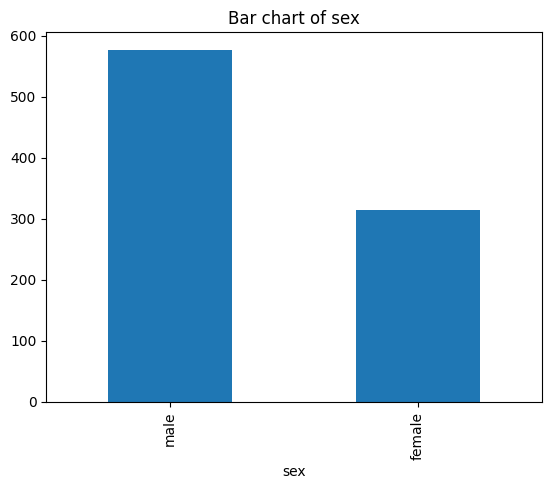

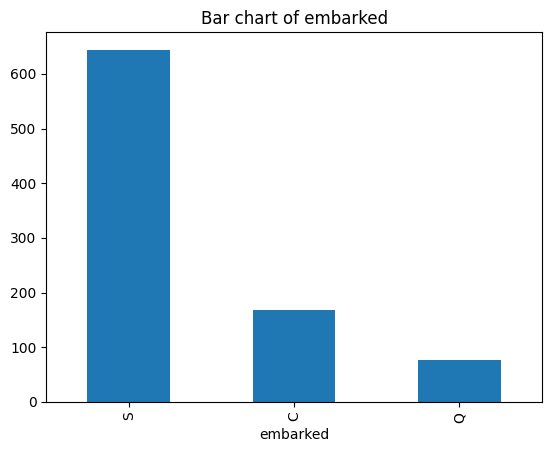

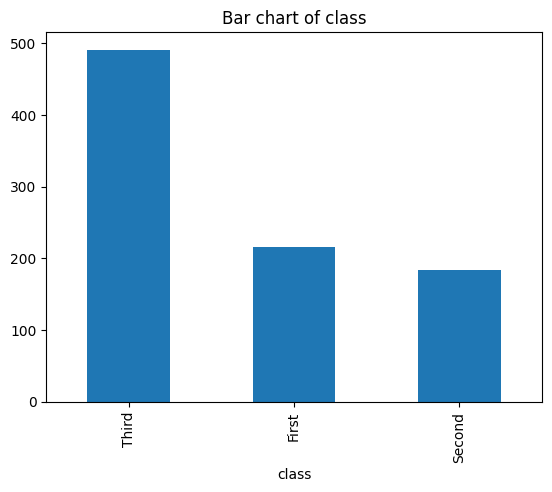

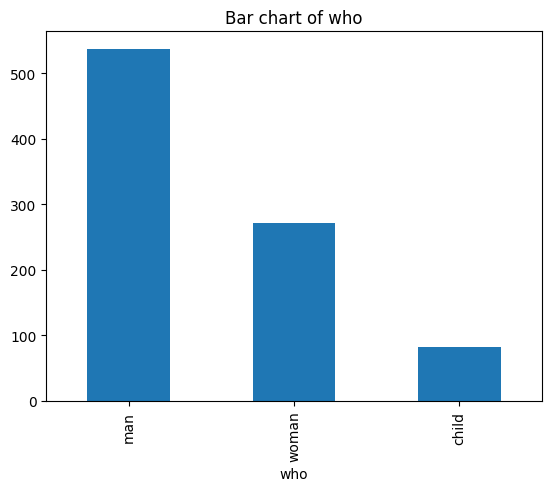

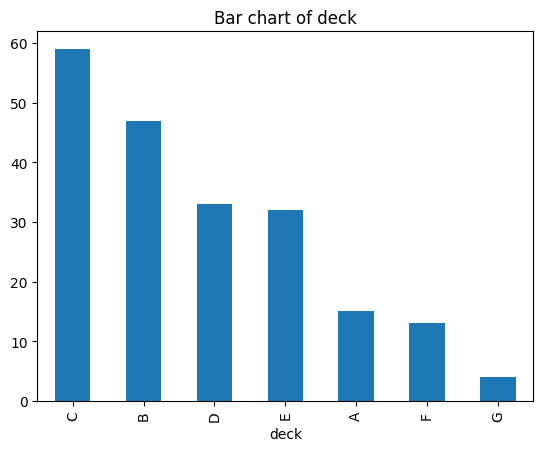

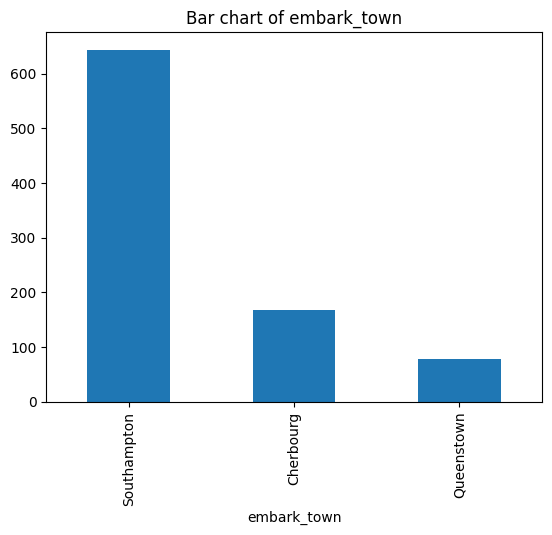

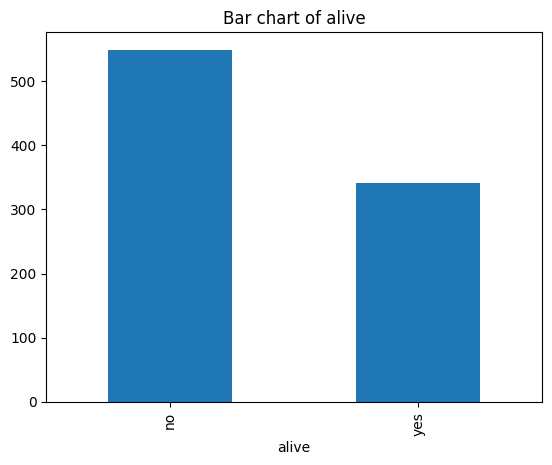

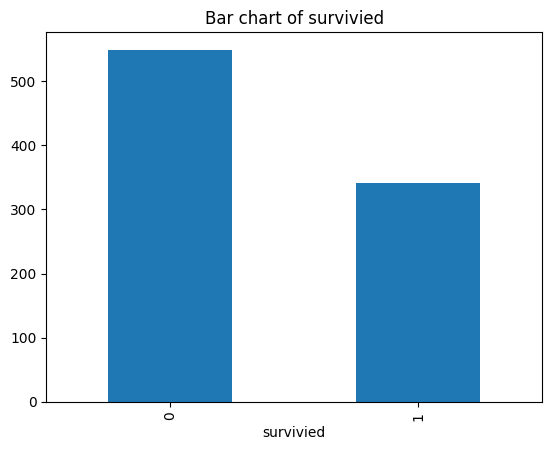

In [337]:
#모든 범주형 변수의 막대그래프 출력하기
category_col = df_titanic.select_dtypes(include=['object','category']).columns

for col in category_col:
  df_titanic[col].value_counts().plot(kind='bar')
    #kind 옵션 'bar', 'pie', 'box', 'kde', 'line', 'scatter'
  plt.title(f'Bar chart of {col}')
  plt.show()

##연습5_1_2

In [338]:
#crosstab 이원분할표(교차표)
titanic_ct=pd.crosstab(df_titanic['class'],df_titanic['alive'], margins=True)
print(titanic_ct)

alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891


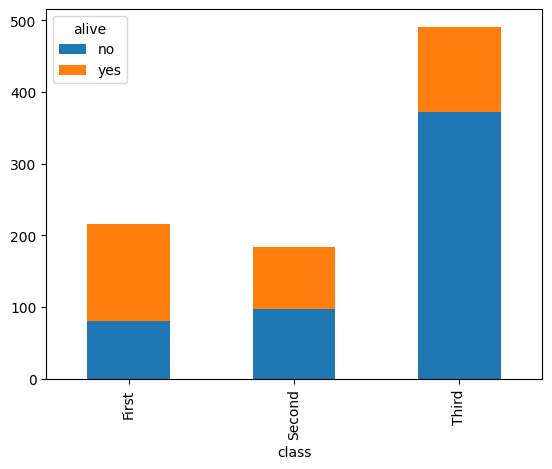

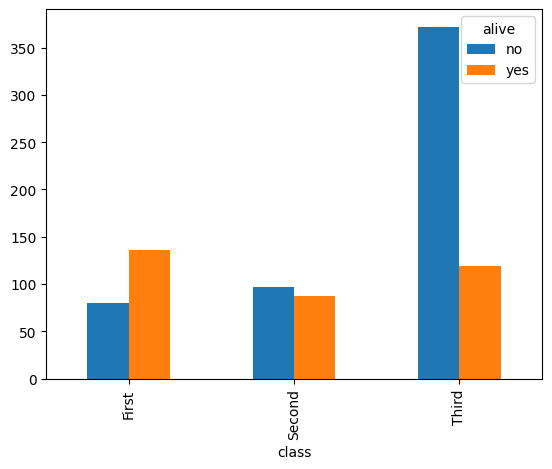

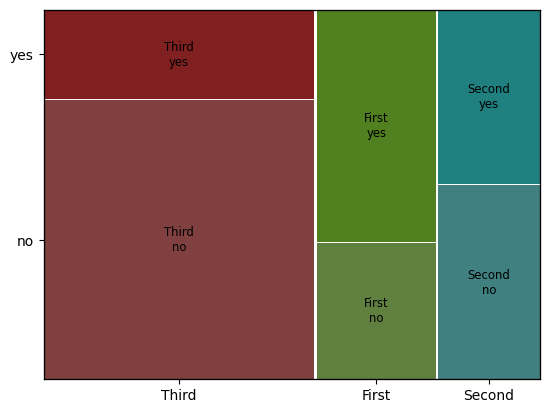

In [339]:
#두 개의 범주형 변수에 대한 막대그래프
titanic_plot=pd.crosstab(df_titanic['class'], df_titanic['alive'])

titanic_plot.plot(kind='bar', stacked=True); plt.show()
titanic_plot.plot(kind='bar', stacked=False); plt.show()

#모자이크 그림
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df_titanic, ['class','alive']); plt.show()

##실행5_2_1. 연속형 변수의 기술통계: 1변수

In [340]:
###실행5_2_1
#모든 연속형 변수의 통계량
print("Descriptive Statistics")
print(df_students.describe())
#describe 행과열 전치
print("\nDescriptive Statistics")
print(df_students.describe().T)

Descriptive Statistics
             id       math    english     science
count  50.00000  50.000000  50.000000   50.000000
mean   25.50000  59.820000  84.280000   63.140000
std    14.57738  20.175445  12.304039   24.278999
min     1.00000  20.000000  55.000000   12.000000
25%    13.25000  46.250000  77.250000   50.000000
50%    25.50000  59.500000  85.500000   65.000000
75%    37.75000  78.750000  97.000000   83.000000
max    50.00000  91.000000  98.000000  103.000000

Descriptive Statistics
         count   mean        std   min    25%   50%    75%    max
id        50.0  25.50  14.577380   1.0  13.25  25.5  37.75   50.0
math      50.0  59.82  20.175445  20.0  46.25  59.5  78.75   91.0
english   50.0  84.28  12.304039  55.0  77.25  85.5  97.00   98.0
science   50.0  63.14  24.278999  12.0  50.00  65.0  83.00  103.0


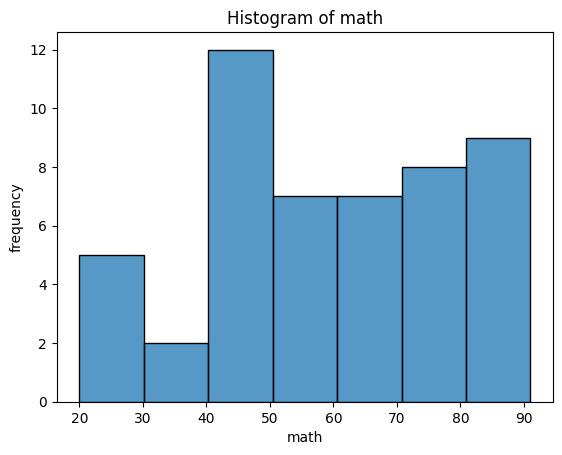

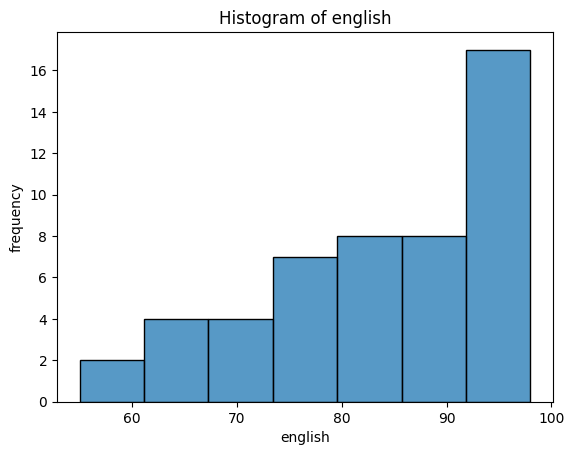

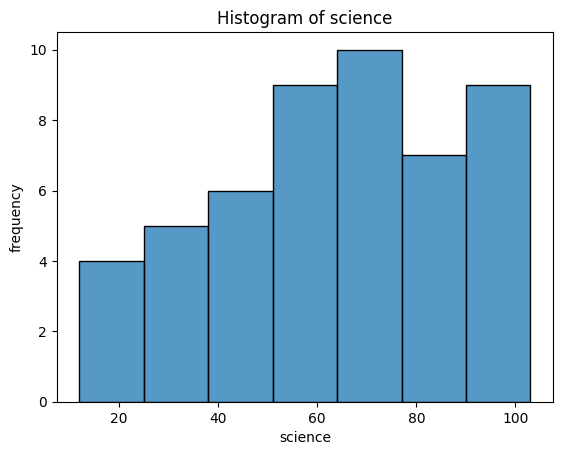

In [341]:
#모든 연속형 변수의 히스토그램 출력하기
df_students['id'] = df_students['id'].astype('category')
conti_col = df_students.select_dtypes(include='number').columns #정수형, 실수형 등 숫자 변수 선택
for col in conti_col:
 sns.histplot(x=col, data=df_students)
 plt.title(f"Histogram of {col}")
 plt.xlabel(col)
 plt.ylabel('frequency')
 plt.show()

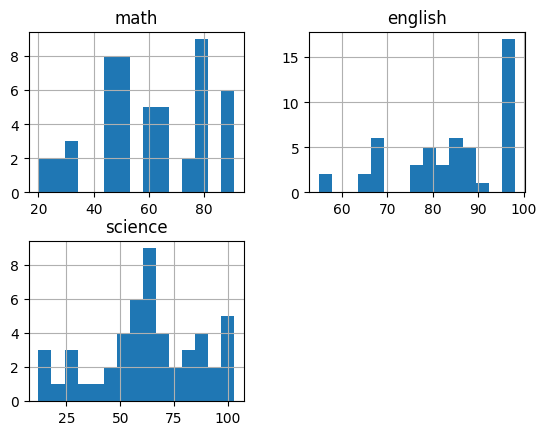

In [342]:
#모든 연속형 변수의 히스토그램 한 페이지 출력하기
df_students[conti_col].hist(bins=15) #pandas의 hist 사용
plt.show()

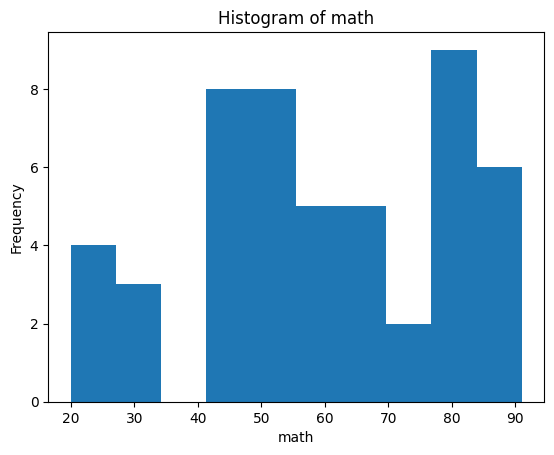

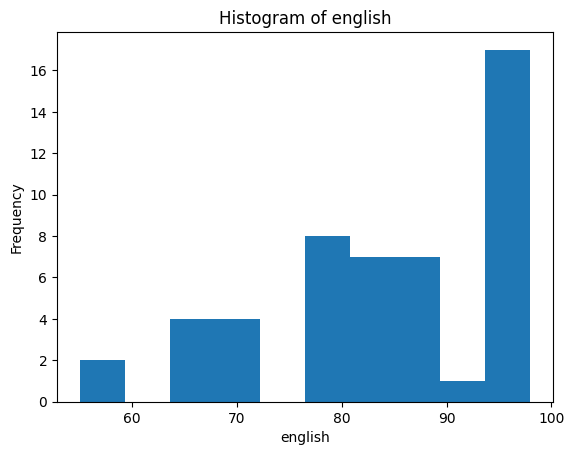

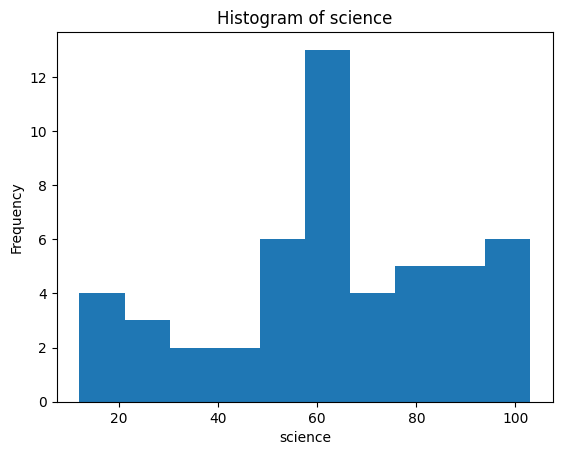

In [343]:
#모든 연속형 변수의 히스토그램 출력하기 plot 사용
for col in conti_col:
 df_students[col].plot(kind='hist')
 #kind 옵션 'box', 'kde', 'hist', 'line', 'bar', 'pie', 'scatter'
 plt.title(f"Histogram of {col}")
 plt.xlabel(col)
 plt.show()

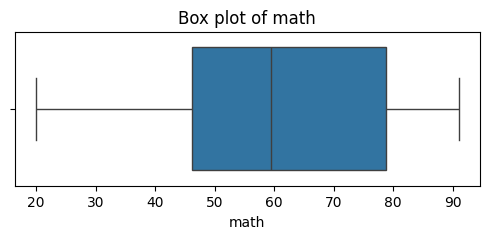

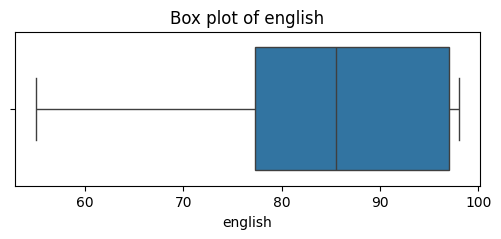

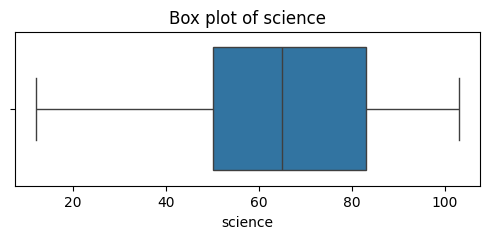

In [344]:
#모든 연속형 변수의 상자그림 출력하기
for col in conti_col:
 plt.figure(figsize=(6, 2))
 sns.boxplot(x=col, data=df_students)
 plt.title(f"Box plot of {col}")
 plt.show()

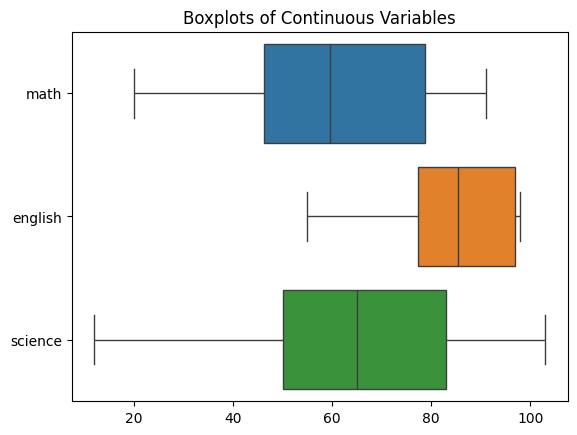

In [345]:
#모든 연속형 변수의 상자그림 한 페이지 출력하기
sns.boxplot(data=df_students[conti_col], orient='h') #orient='v' 가 디폴트
plt.title("Boxplots of Continuous Variables")
plt.show()

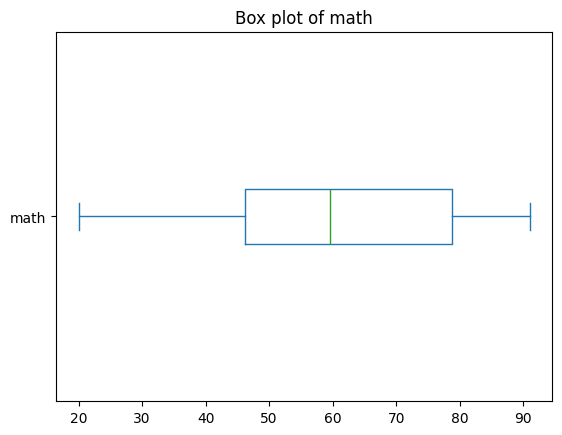

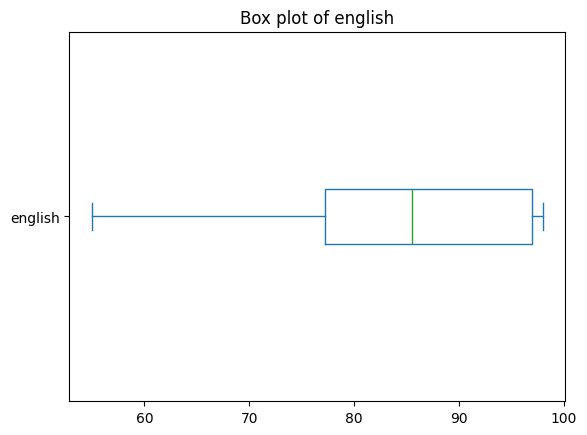

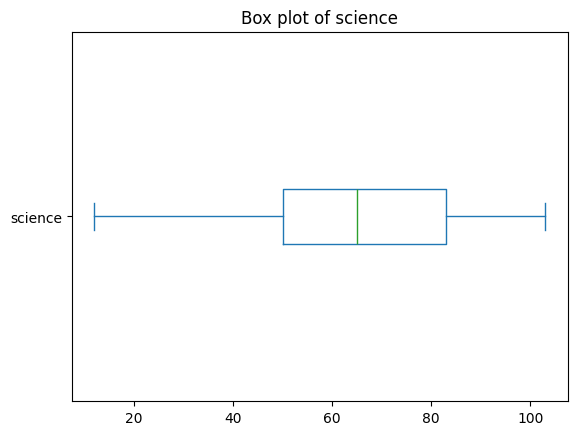

In [346]:
#모든 연속형 변수의 상자그림 출력하기 plot 사용
for col in conti_col:
# plt.figure(figsize=(6, 2))
 df_students[col].plot(kind='box',vert=False) #vert는 세로로 표시여부
 plt.title(f"Box plot of {col}")
 plt.show()

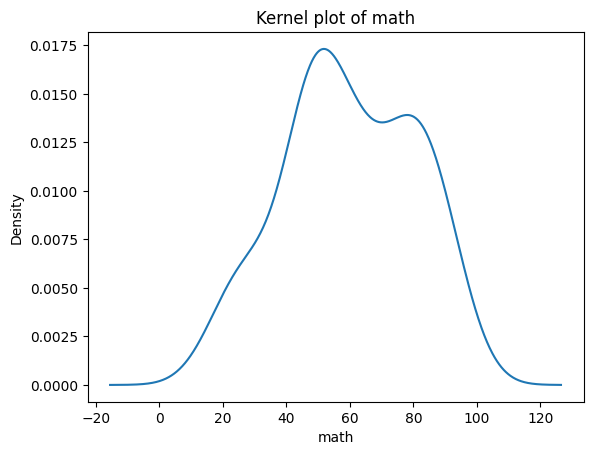

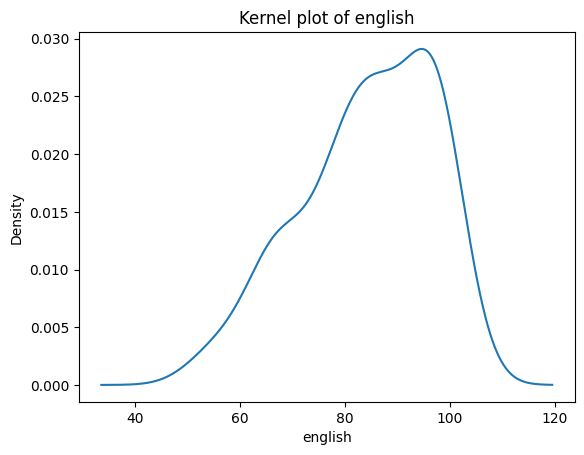

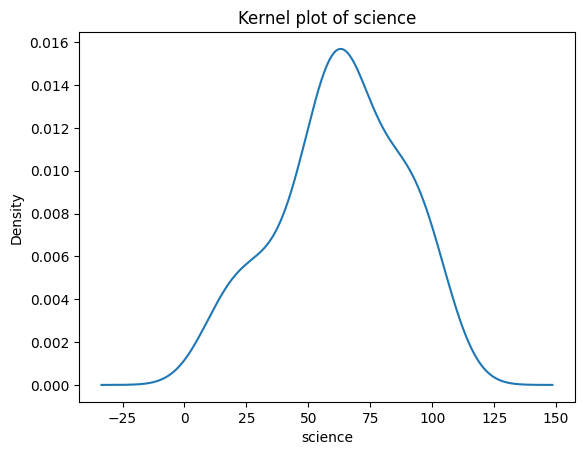

In [347]:
#모든 연속형 변수의 Kernel Density Estimate Plot 출력하기 plot 사용
for col in conti_col:
 df_students[col].plot(kind='kde')
 plt.title(f"Kernel plot of {col}")
 plt.xlabel(col)
 plt.show()

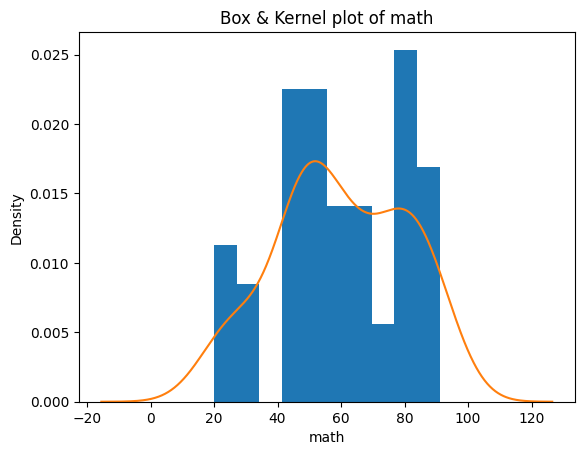

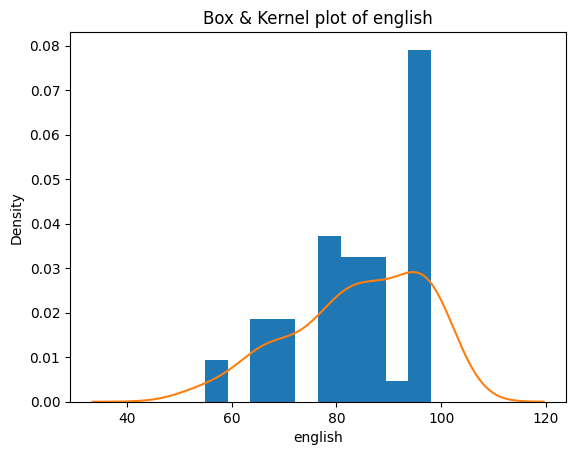

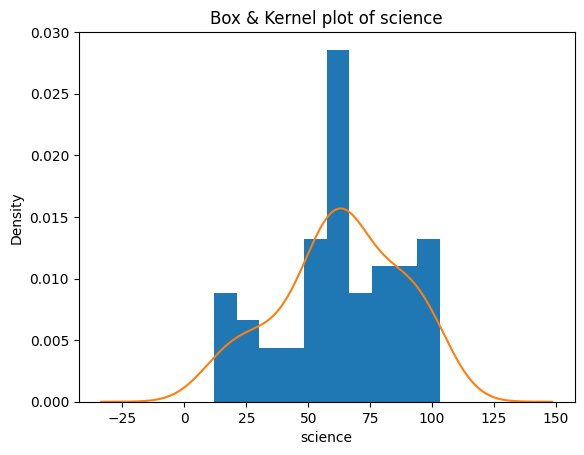

In [348]:
#모든 연속형 변수의 히스토그램과 커널밀도함수 겹쳐그리기
for col in conti_col:
 df_students[col].plot(kind='hist', density=True)
 df_students[col].plot(kind='kde')
 plt.title(f"Box & Kernel plot of {col}")
 plt.xlabel(col)
 plt.show()

##실행5_2_2. 연속형 변수의 기술통계: 2변수

In [349]:
#연속형 변수들의 상관계수
print("[Correlation]")
print(df_students['math'].corr(df_students['english']))

#Pearson 상관행렬
print("\n[Pearson corr matrix]")
print(df_students[conti_col].corr())

[Correlation]
-0.5510215866263541

[Pearson corr matrix]
             math   english   science
math     1.000000 -0.551022  0.219408
english -0.551022  1.000000 -0.417138
science  0.219408 -0.417138  1.000000


In [350]:
#Spearman 상관행렬
print("\n[Spearman corr matrix]")
print(df_students[['math', 'english', 'science']].corr(method='spearman')) #method 옵션 'pearson'이 기본, 'spearman', 'kendall'

#특정 변수랑만 보고싶을 때
print("\n[Correlation of Each Variable with 'math']")
print(df_students[['math', 'english', 'science']].corrwith(df_students['math']))


[Spearman corr matrix]
             math   english   science
math     1.000000 -0.570439  0.177134
english -0.570439  1.000000 -0.444489
science  0.177134 -0.444489  1.000000

[Correlation of Each Variable with 'math']
math       1.000000
english   -0.551022
science    0.219408
dtype: float64


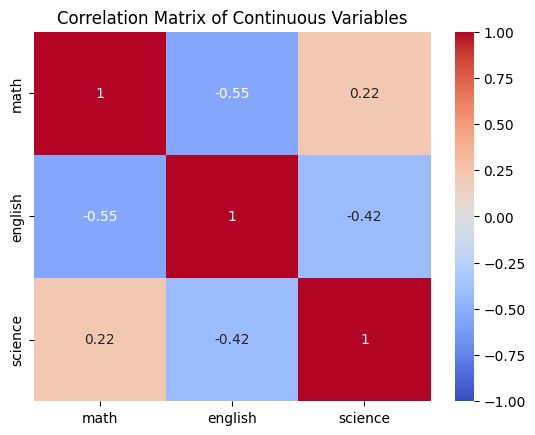

In [351]:
#heatmap(값의 크기를 색깔로 표현하는 그래프)로 상관계수 그래프 그리기
students_corr = df_students[['math', 'english', 'science']].corr()
sns.heatmap(students_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1) #annot=True 수치가 나타남

#annot 셀 내부에 수치 표시/cmap 색상 팔레트 선택 'grey' 등/vmin 색상의 최소값 기준
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

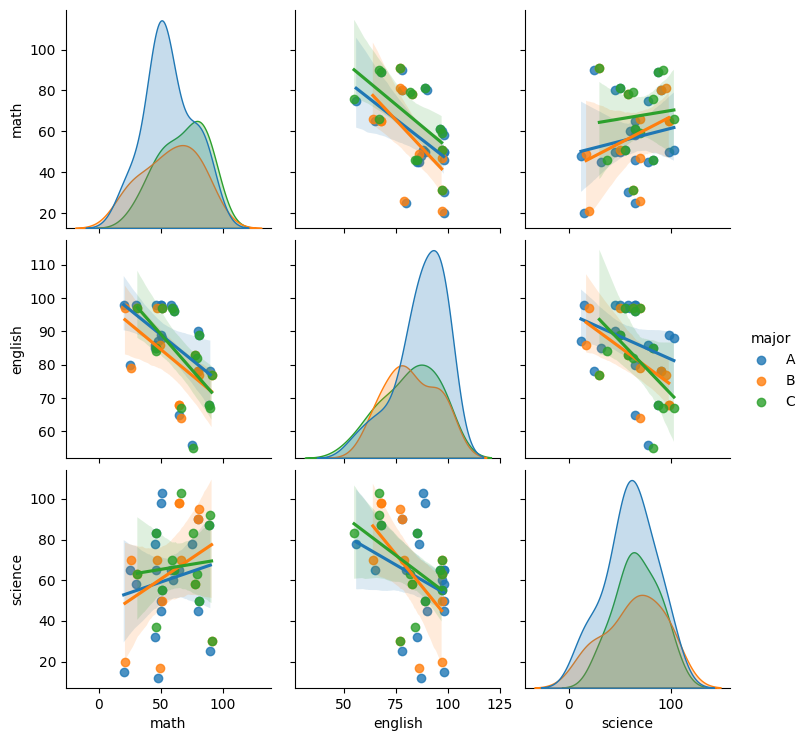

In [352]:
#산점도 행렬 그리기
sns.pairplot(data=df_students, vars=['math','english','science'], hue='major', kind='reg')
plt.show()

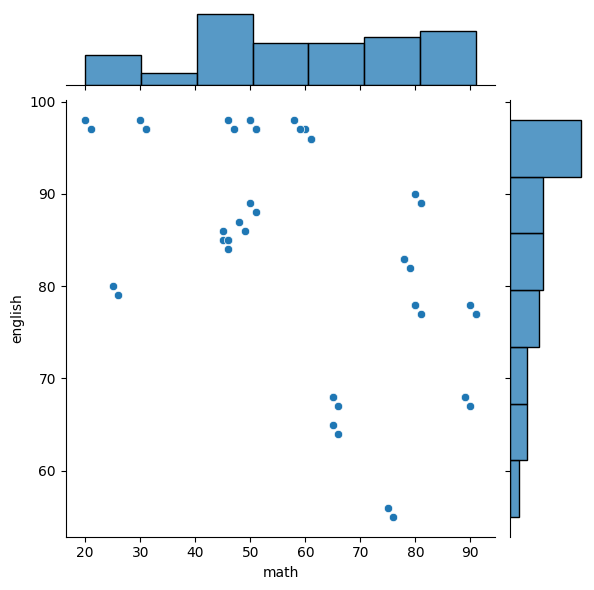

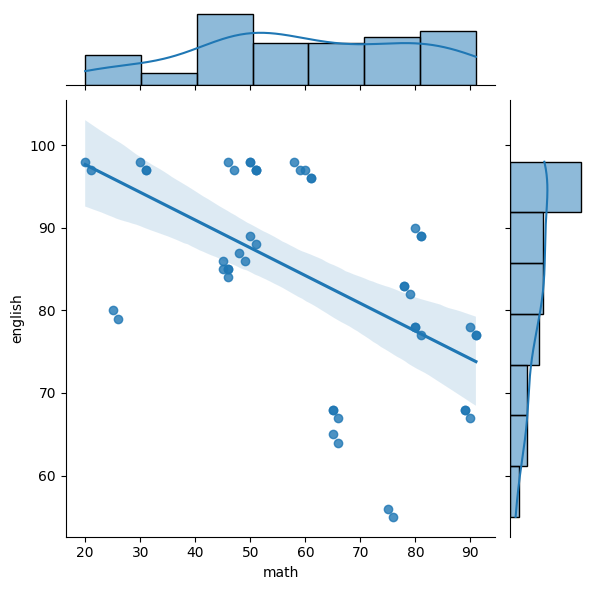

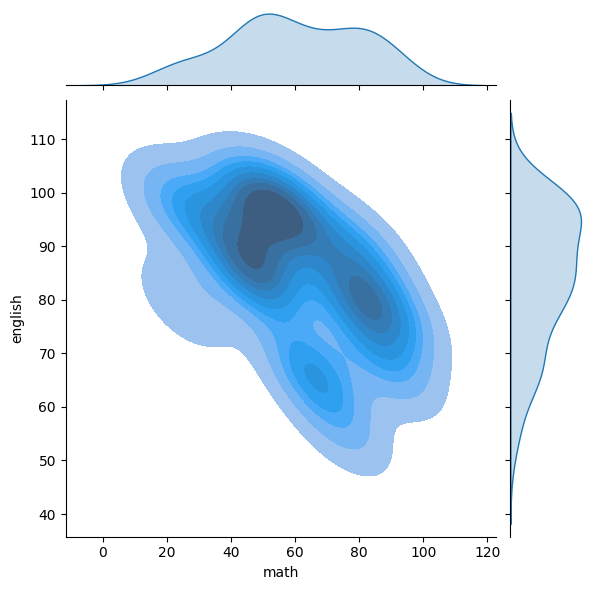

In [353]:
#jointplot으로 두 개의 연속형 변수 사이의 관계를 한눈에 보여주는 그래프 그리기
sns.jointplot(x='math', y='english', data=df_students, kind='scatter') #산점도
plt.show()
sns.jointplot(x='math', y='english', data=df_students, kind='reg') #회귀선
plt.show()
sns.jointplot(x='math',y='english',data=df_students, kind='kde', fill=True) #Kernel그래프 ,fill=True를 써야 등고선 안에 색이 채워
plt.show()

#연습5_2_1

In [354]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    category
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  survivied    891 non-null    category
dtypes: bool(2), category(4), float64(2), int64(3), object(5)
memory usage: 75.7+ KB


In [355]:
#모든 연속형 변수의 통계량
conti_col=df_titanic.select_dtypes(include='number').columns
print(df_titanic[conti_col].describe())

#describe 행과 열 전치
print(df_titanic[conti_col].describe().T)

         survived         age       sibsp       parch        fare
count  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838   29.699118    0.523008    0.381594   32.204208
std      0.486592   14.526497    1.102743    0.806057   49.693429
min      0.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000   80.000000    8.000000    6.000000  512.329200
          count       mean        std   min      25%      50%   75%       max
survived  891.0   0.383838   0.486592  0.00   0.0000   0.0000   1.0    1.0000
age       714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000
sibsp     891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000
parch     891.0   0.381594   0.806057  0.00   0.0000   0.0000   0.0    6.0000
fare      891.0 

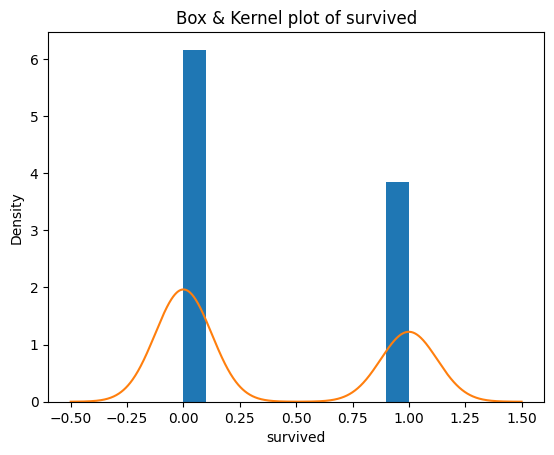

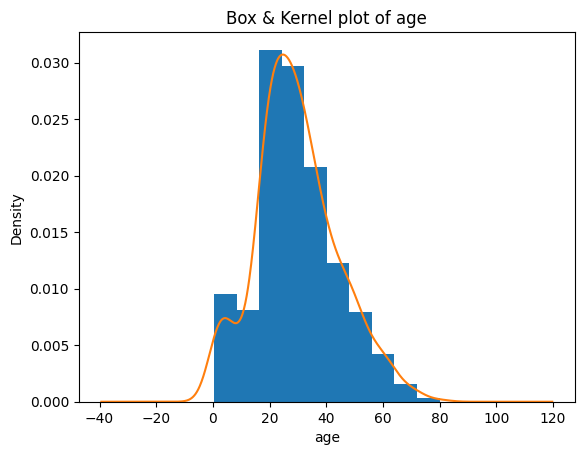

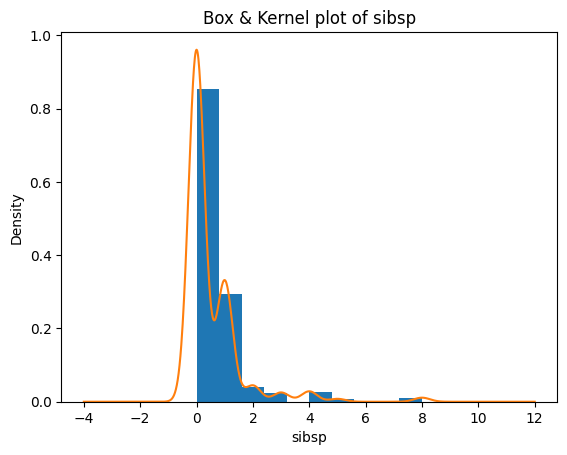

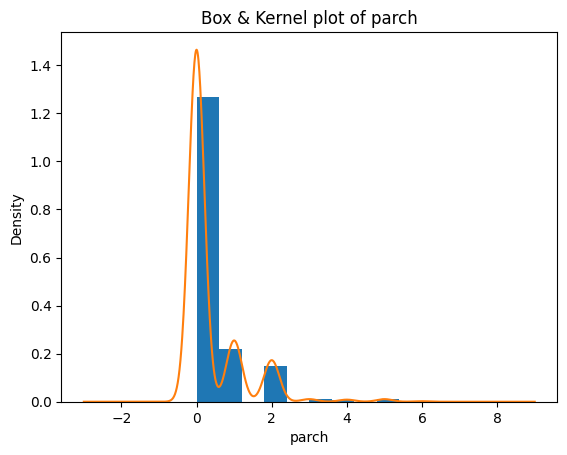

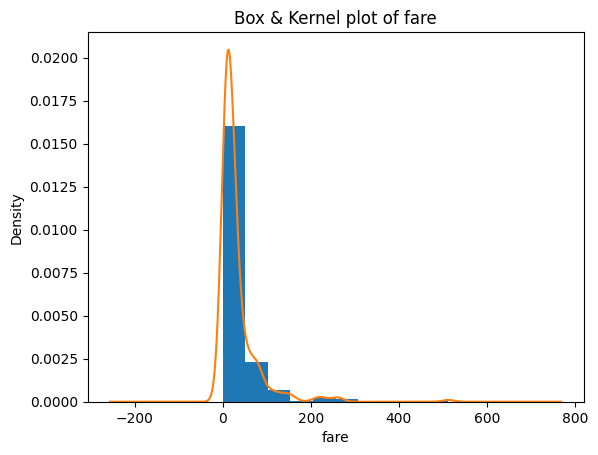

In [356]:
#모든 연속형 변수의 히스토그램과 커널밀도함수 겹쳐그리기
conti_col=df_titanic.select_dtypes(include='number').columns  #불린형은 넘버에 포함되지 않음
for col in conti_col:
  df_titanic[col].plot(kind='hist', density=True) #density=True로 상대빈도가 보이게 표시해줘야 함
  df_titanic[col].plot(kind='kde')
  plt.title(f"Box & Kernel plot of {col}")
  plt.xlabel(col)
  plt.show()

#연습5_2_2

In [357]:
#피어슨 상관계수
print("\n[Pearson corr matrix]")
print(df_titanic[conti_col].corr())


[Pearson corr matrix]
          survived       age     sibsp     parch      fare
survived  1.000000 -0.077221 -0.035322  0.081629  0.257307
age      -0.077221  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322 -0.308247  1.000000  0.414838  0.159651
parch     0.081629 -0.189119  0.414838  1.000000  0.216225
fare      0.257307  0.096067  0.159651  0.216225  1.000000


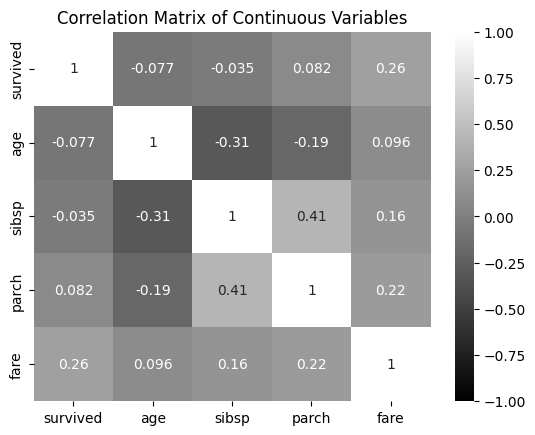

In [358]:
#heatmap(값의 크기를 색깔로 표현하는 그래프)로 상관계수 그래프 그리기
titanic_corr=df_titanic[conti_col].corr()

sns.heatmap(titanic_corr, annot=True, cmap='grey', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

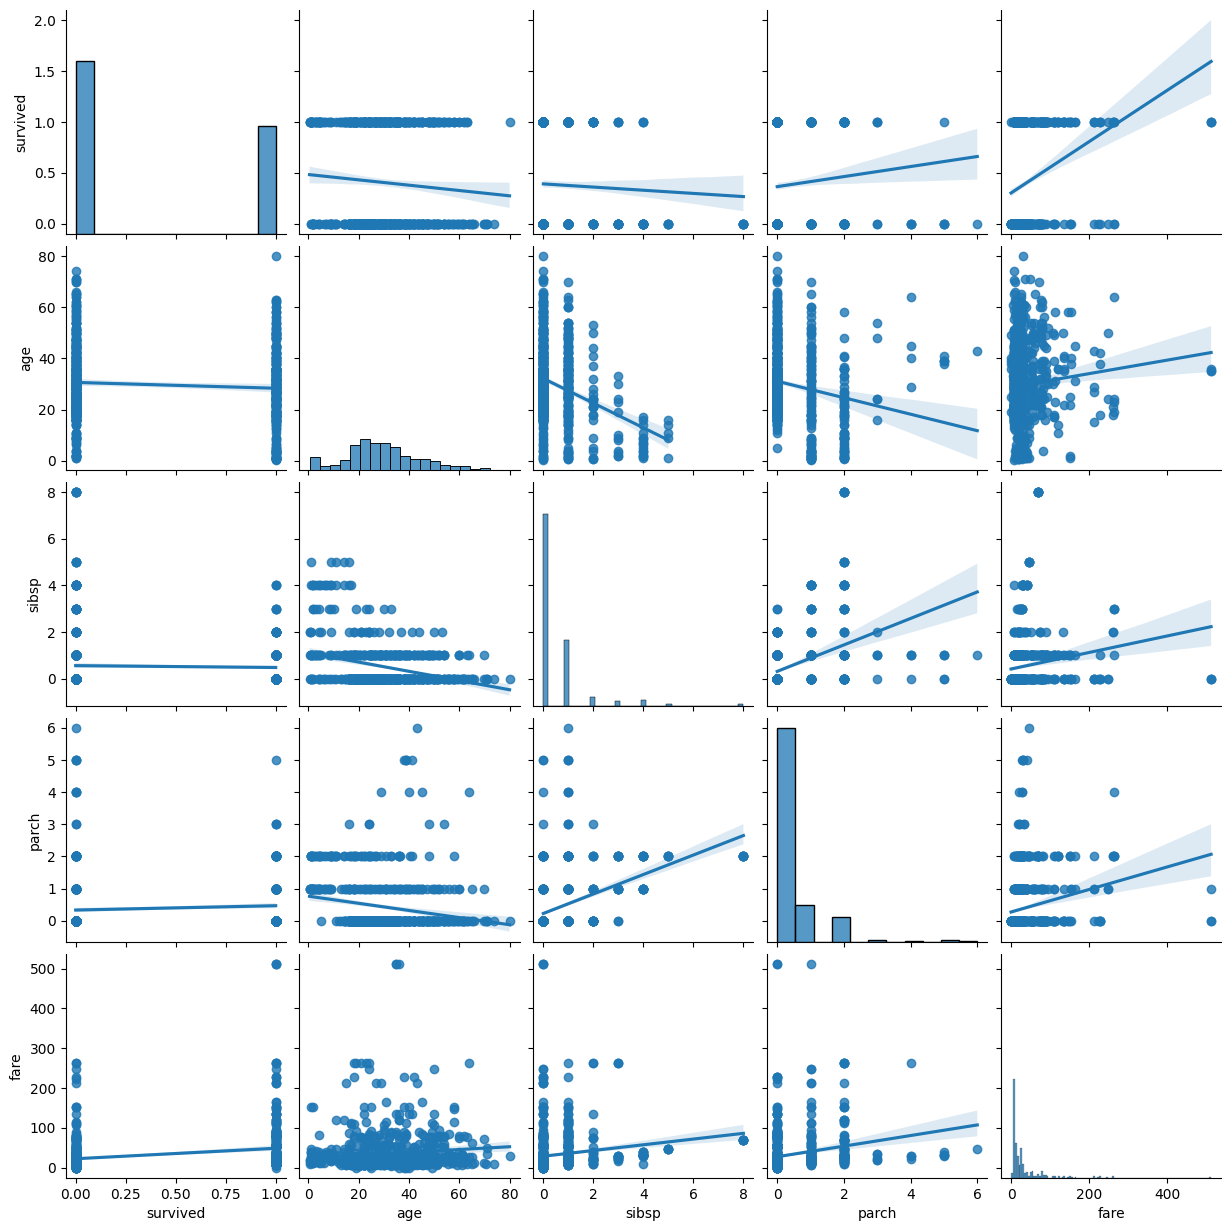

In [359]:
#산점도 행렬 그리기
sns.pairplot(data=df_titanic, vars=conti_col, kind='reg')
plt.show()

#연습5_2_3

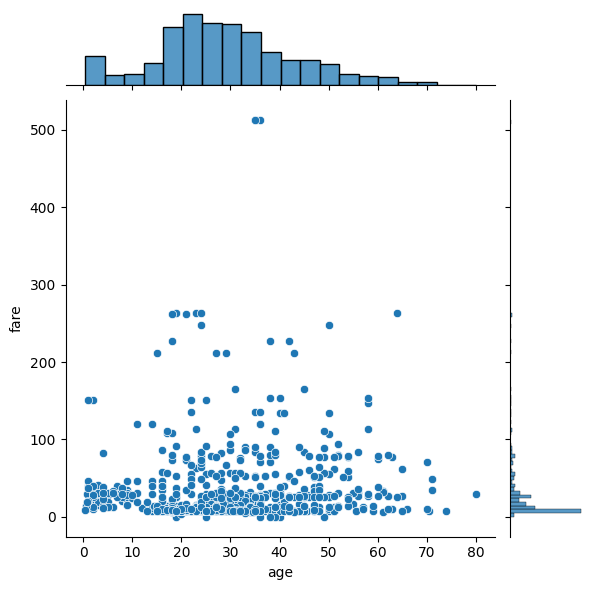

In [360]:
sns.jointplot(x='age',y='fare', data=df_titanic, kind='scatter') #산점도
plt. show()

#실행 5_3_1

In [361]:
#그룹별 연속형변수의 평균
df_students.groupby('grade')['math'].quantile(0.25)
#count, sum, std, median, min, max, quantile(0.25), quantile(0.75) 등 적용가능

,math
grade,
grade1,38.00
grade2,46.00
grade3,48.25
grade4,79.25


<Axes: xlabel='grade'>

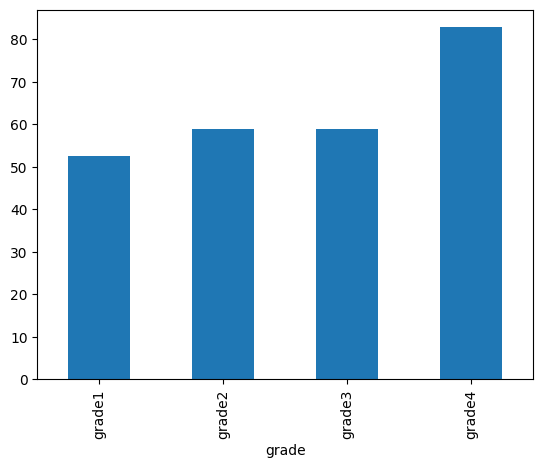

In [362]:
#그룹별 연속형변수의 평균 그래프
df_students.groupby('grade')['math'].mean().plot(kind='bar')

In [363]:
#그룹별 연속형변수의 다양한 통계량 보기 - groupby 사용
for col in ['math', 'english', 'science']:
 print(f"\nStatistics of {col}")
 students_pt1 = df_students.groupby('grade')[col].agg(['count', 'mean', 'std'])   #통계량 여러개 출력하려면 agg 쓰면 됨, quantile은 안됨
 print(students_pt1)


Statistics of math
        count       mean        std
grade                              
grade1     15  52.533333  19.927966
grade2     19  58.789474  22.458799
grade3     10  58.900000  11.376877
grade4      6  82.833333   5.269409

Statistics of english
        count       mean        std
grade                              
grade1     15  87.133333  10.888176
grade2     19  86.473684  10.410296
grade3     10  80.900000  17.691492
grade4      6  75.833333   6.853223

Statistics of science
        count       mean        std
grade                              
grade1     15  69.000000  14.706655
grade2     19  51.368421  25.031559
grade3     10  66.100000  30.142071
grade4      6  80.833333  16.042651


In [364]:
#그룹별 연속형변수의 다양한 통계량 보기 - pivot_table 사용
students_pt2 = df_students.pivot_table(
 index='grade',
 values=['math', 'english', 'science'],
 aggfunc=['count', 'mean', 'std'])  #계량 여러개 출력하려면 aggfunc 쓰면 됨, quantile은 안됨
print(students_pt2)

         count                    mean                              std  \
       english math science    english       math    science    english   
grade                                                                     
grade1      15   15      15  87.133333  52.533333  69.000000  10.888176   
grade2      19   19      19  86.473684  58.789474  51.368421  10.410296   
grade3      10   10      10  80.900000  58.900000  66.100000  17.691492   
grade4       6    6       6  75.833333  82.833333  80.833333   6.853223   

                              
             math    science  
grade                         
grade1  19.927966  14.706655  
grade2  22.458799  25.031559  
grade3  11.376877  30.142071  
grade4   5.269409  16.042651  


In [365]:
#그룹별 연속형변수의 다양한 통계량 보기 - pivot_table 변수별로
for col in ['math', 'english', 'science']:
 print(f"\n{col} 통계")
 students_pt3 = df_students.pivot_table(
 index='grade',
 values=col,
 aggfunc=['count', 'mean', 'std'])
 students_pt3.columns = students_pt3.columns.droplevel(1) #결과의 2행 헤더 삭제
 print(students_pt3)


math 통계
        count       mean        std
grade                              
grade1     15  52.533333  19.927966
grade2     19  58.789474  22.458799
grade3     10  58.900000  11.376877
grade4      6  82.833333   5.269409

english 통계
        count       mean        std
grade                              
grade1     15  87.133333  10.888176
grade2     19  86.473684  10.410296
grade3     10  80.900000  17.691492
grade4      6  75.833333   6.853223

science 통계
        count       mean        std
grade                              
grade1     15  69.000000  14.706655
grade2     19  51.368421  25.031559
grade3     10  66.100000  30.142071
grade4      6  80.833333  16.042651


In [366]:
#전체(All) 추가
students_pt4 = df_students.pivot_table(
 index='grade', #학년별 통계
 values=['math', 'english'],
 aggfunc=['count', 'mean', 'std'],
 margins=True) #전체(All) 행 추가
print(students_pt4)

         count            mean                   std           
       english math    english       math    english       math
grade                                                          
grade1      15   15  87.133333  52.533333  10.888176  19.927966
grade2      19   19  86.473684  58.789474  10.410296  22.458799
grade3      10   10  80.900000  58.900000  17.691492  11.376877
grade4       6    6  75.833333  82.833333   6.853223   5.269409
All         50   50  84.280000  59.820000  12.304039  20.175445


In [367]:
#다양한 통계량 추가
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)
def kurt(x): return x.kurt()
students_pt5 = df_students.pivot_table(
 index='grade',
 values=['math', 'english'],
 aggfunc=['count', 'mean', 'std', q25, 'median', q75, 'skew', kurt])  #skew: 왜도, kurt: 첨도-이거는 제공 안함
 #agg 옵션에는 quantile(0.25), quantile(0.75) 사용불가
print(students_pt5)

         count            mean                   std                q25  \
       english math    english       math    english       math english   
grade                                                                     
grade1      15   15  87.133333  52.533333  10.888176  19.927966   79.50   
grade2      19   19  86.473684  58.789474  10.410296  22.458799   81.00   
grade3      10   10  80.900000  58.900000  17.691492  11.376877   67.25   
grade4       6    6  75.833333  82.833333   6.853223   5.269409   70.25   

               median           q75             skew                kurt  \
         math english  math english   math   english      math   english   
grade                                                                      
grade1  38.00    86.0  51.0    97.0  63.00 -0.552162  0.281022 -0.999425   
grade2  46.00    89.0  51.0    96.5  80.50 -0.883932 -0.074421  0.191137   
grade3  48.25    86.5  58.5    97.0  65.75 -0.475014  0.345252 -1.650449   
grade4  79.25    7

In [368]:
#그룹변수 여러개
students_pt6 = df_students.pivot_table(
 index=['grade', 'major'],
 values=['math','english'],
 aggfunc=['count', 'mean', 'std', q25, 'median', q75])
print(students_pt6)

               count            mean                   std                q25  \
             english math    english       math    english       math english   
grade  major                                                                    
grade1 A           8    8  92.125000  46.000000   7.239524  12.873006   85.75   
       B           4    4  80.500000  50.500000  12.069245  26.210685   75.50   
       C           3    3  82.666667  72.666667  14.502873  19.553346   75.50   
grade2 A           9    9  86.666667  59.111111  10.173495  21.979789   85.00   
       B           4    4  83.750000  57.250000  16.194135  29.261750   73.75   
       C           6    6  88.000000  59.333333   7.641989  22.949219   84.25   
grade3 A           4    4  84.750000  56.750000  19.855730  13.250786   79.25   
       B           3    3  83.666667  53.666667  14.640128   9.865766   77.00   
       C           3    3  73.000000  67.000000  21.633308   8.544004   61.00   
grade4 A           2    2  7

In [369]:
students_pt7 = df_students.pivot_table(
 index='grade',
 columns='major', #major를 열로
 values='math',
 aggfunc=['count', 'mean', 'std', q25, 'median', q75])
print(students_pt7)

       count             mean                              std             \
major      A  B  C          A          B          C          A          B   
grade                                                                       
grade1     8  4  3  46.000000  50.500000  72.666667  12.873006  26.210685   
grade2     9  4  6  59.111111  57.250000  59.333333  21.979789  29.261750   
grade3     4  3  3  56.750000  53.666667  67.000000  13.250786   9.865766   
grade4     2  2  2  84.500000  79.500000  84.500000   6.363961   2.121320   

                     q25               median                q75                
major           C      A      B      C      A     B     C      A      B      C  
grade                                                                           
grade1  19.553346  41.25  29.75  64.50   48.0  48.0  78.0  53.25  68.75  83.50  
grade2  22.949219  50.00  43.50  46.00   51.0  58.5  53.5  80.00  72.25  76.00  
grade3   8.544004  47.50  48.00  62.50   53.0  49.0  66

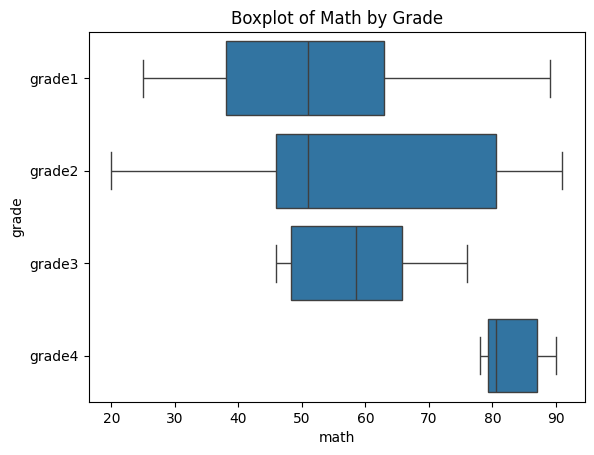

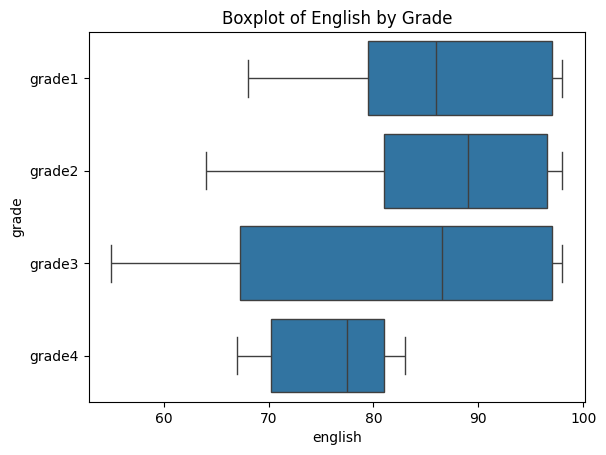

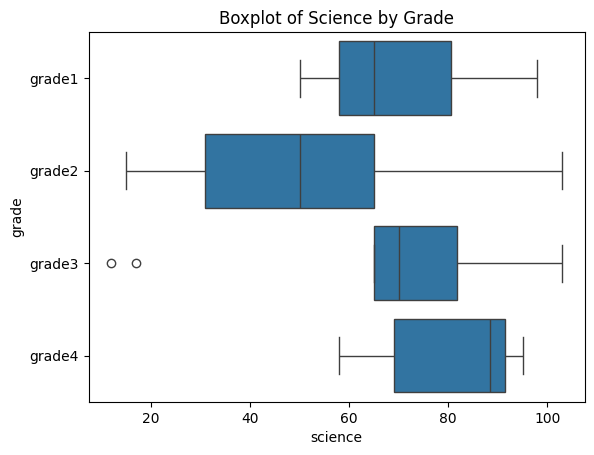

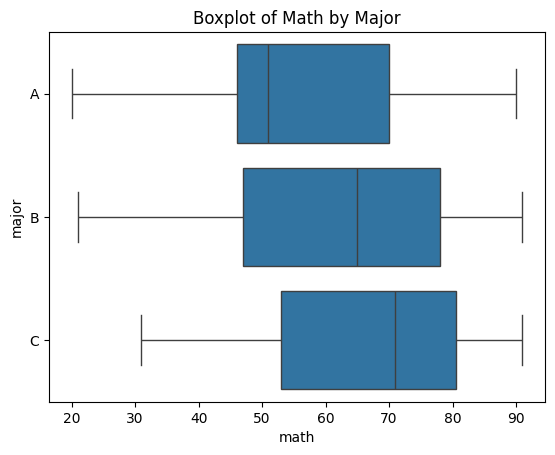

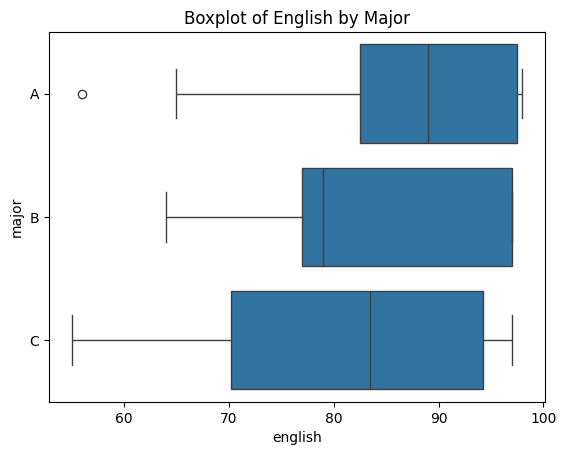

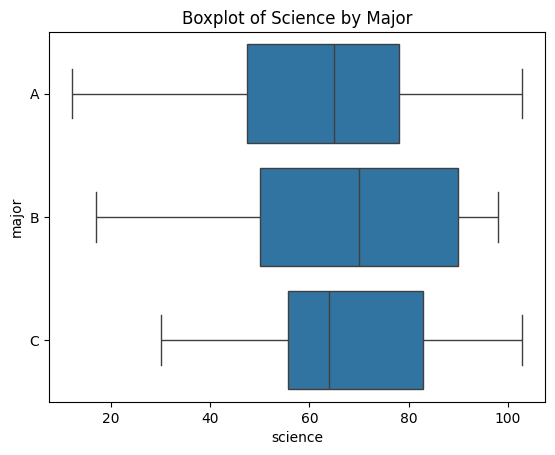

In [370]:
#그룹변수별 연속형 변수의 상자그림
category_col=df_students.select_dtypes(include=['object', 'category']).columns.drop('id')
conti_col = df_students.select_dtypes(include='number').columns
for y in category_col:
 for x in conti_col:
  sns.boxplot(x=x, y=y, data=df_students)
  plt.title(f'Boxplot of {x.capitalize()} by {y.capitalize()}')
  plt.show()

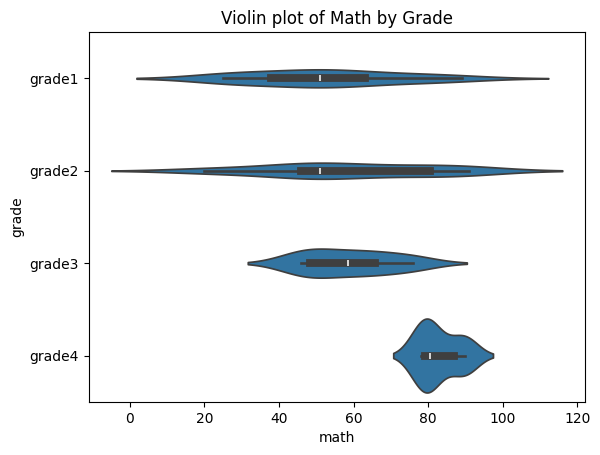

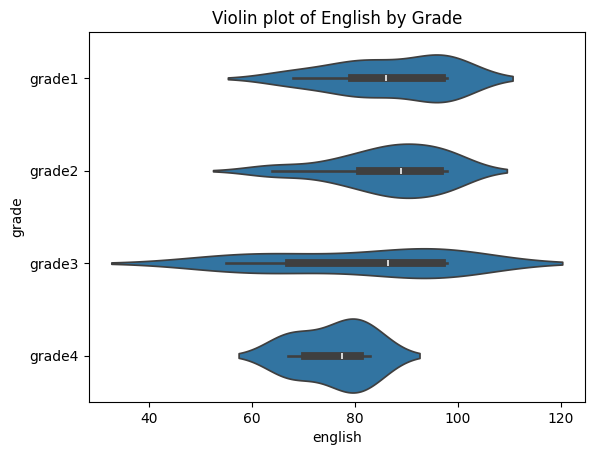

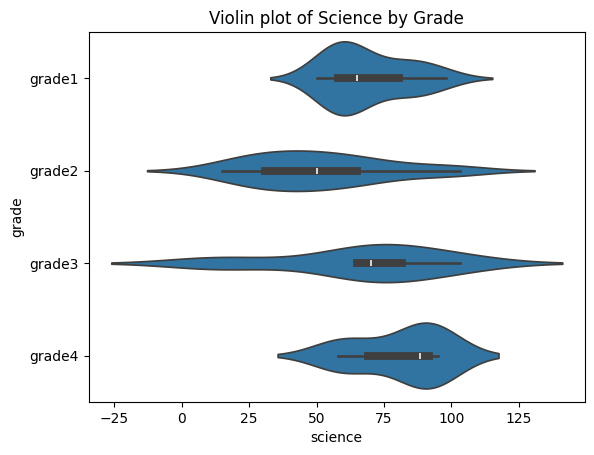

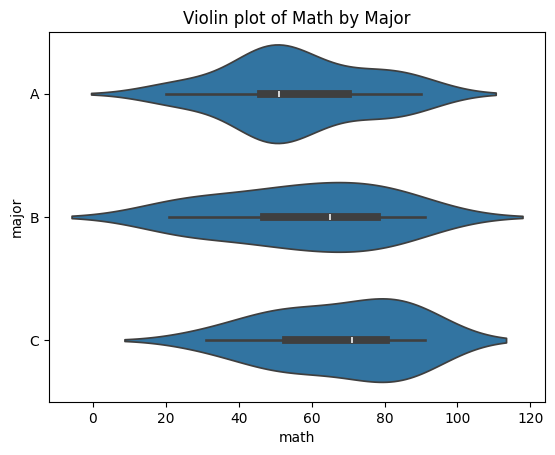

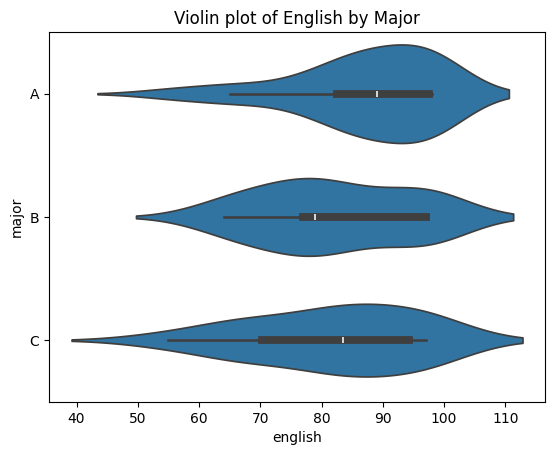

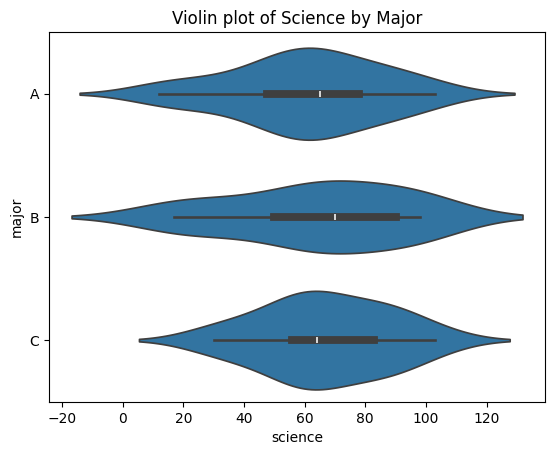

In [371]:
#그룹변수별 연속형 변수의 바이올린그림
for y in category_col:
 for x in conti_col:
  sns.violinplot(x=x, y=y, data=df_students)
  plt.title(f'Violin plot of {x.capitalize()} by {y.capitalize()}')
  plt.show()

#연습5_3_1

alive
no     22.117887
yes    48.395408
Name: fare, dtype: float64


<Axes: xlabel='alive'>

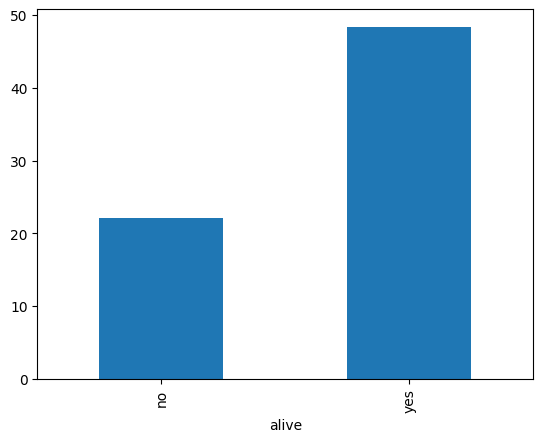

In [372]:
#그룹별 연속형변수의 평균
print(df_titanic.groupby('alive')['fare'].mean())

#그룹별 연속형변수의 평균 그래프
df_titanic.groupby('alive')['fare'].mean().plot(kind='bar')

#연습5_3_2

In [376]:
for col in ['age','fare','sibsp','parch']:
  print(f"\n[Statistics of {col}]")
  titanic_pt1=df_titanic.groupby('alive')[col].agg(['count','mean','std','min','max'])
  print(titanic_pt1)


[Statistics of age]
       count       mean        std   min   max
alive                                         
no       424  30.626179  14.172110  1.00  74.0
yes      290  28.343690  14.950952  0.42  80.0

[Statistics of fare]
       count       mean        std  min       max
alive                                            
no       549  22.117887  31.388207  0.0  263.0000
yes      342  48.395408  66.596998  0.0  512.3292

[Statistics of sibsp]
       count      mean       std  min  max
alive                                     
no       549  0.553734  1.288399    0    8
yes      342  0.473684  0.708688    0    4

[Statistics of parch]
       count      mean       std  min  max
alive                                     
no       549  0.329690  0.823166    0    6
yes      342  0.464912  0.771712    0    5


In [373]:
#그룹별 연속형변수의 다양한 통계량 보기-groupby 사용
conti_col=df_titanic.select_dtypes(include='number').columns.drop('survived')

for col in conti_col:
  print(f"\n[Statistics of {col}]")
  titanic_pt1=df_titanic.groupby('alive')[col].agg(['count','mean','std','min','max'])
  print(titanic_pt1)


[Statistics of age]
       count       mean        std   min   max
alive                                         
no       424  30.626179  14.172110  1.00  74.0
yes      290  28.343690  14.950952  0.42  80.0

[Statistics of sibsp]
       count      mean       std  min  max
alive                                     
no       549  0.553734  1.288399    0    8
yes      342  0.473684  0.708688    0    4

[Statistics of parch]
       count      mean       std  min  max
alive                                     
no       549  0.329690  0.823166    0    6
yes      342  0.464912  0.771712    0    5

[Statistics of fare]
       count       mean        std  min       max
alive                                            
no       549  22.117887  31.388207  0.0  263.0000
yes      342  48.395408  66.596998  0.0  512.3292


#연습5_3_3

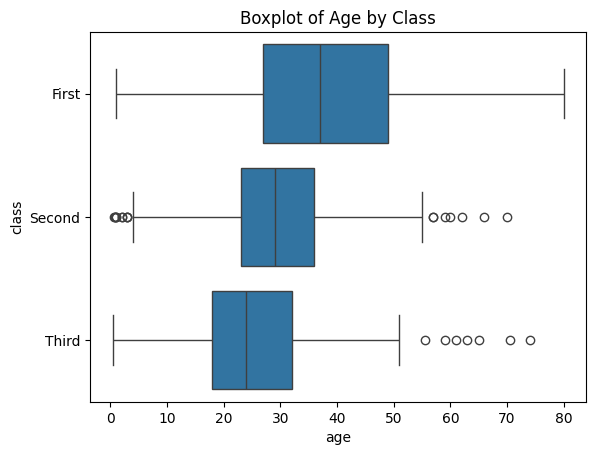

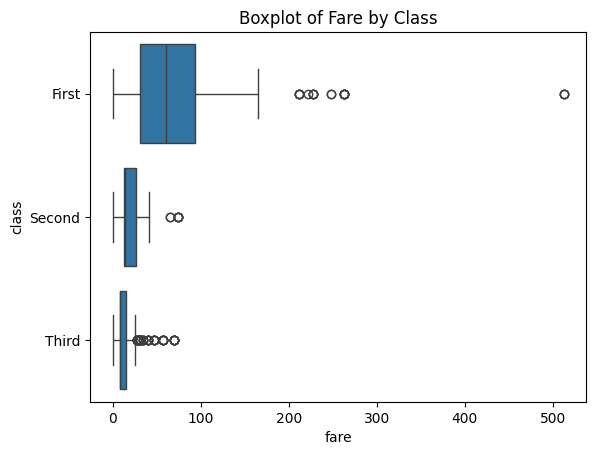

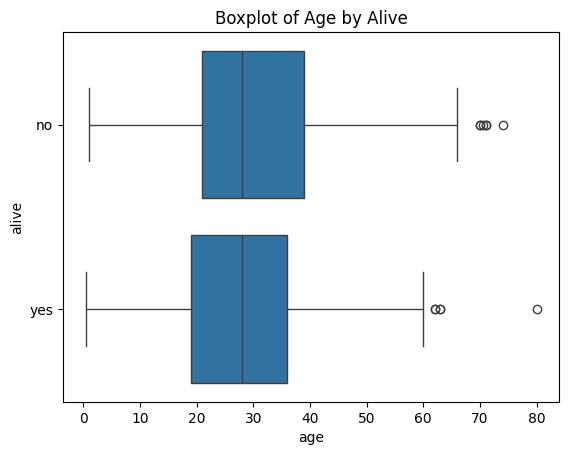

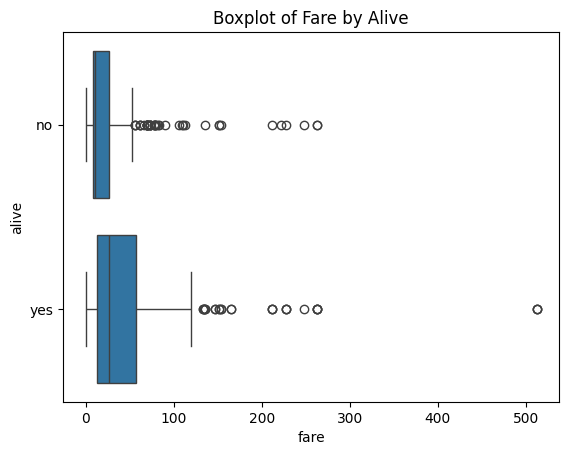

In [374]:
#그룹변수별 연속형 변수의 상자그림
for y in ['class','alive']:
  for x in ['age','fare']:
    sns.boxplot(x=x, y=y, data=df_titanic)
    plt.title(f'Boxplot of {x.capitalize()} by {y.capitalize()}')
    plt.show()